In [1]:
import os
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set up the folder path in Google Drive
folder_path = r'/content/drive/My Drive/Factordata'

# Function to inspect columns of Excel files
def inspect_excel_file_columns(file_path):
    try:
        # Load the specified sheet from the Excel file
        df = pd.read_excel(file_path, sheet_name="FactorOutput")
        print(f"File: {file_path}")
        print("Columns in the FactorOutput sheet:")
        print(df.columns.tolist())
        print("-" * 40)
        return df.columns.tolist()
    except Exception as e:
        print(f"Error inspecting {file_path}: {e}")
        return None

# Inspect columns in all files in the specified folder
print("Inspecting columns in each file...\n")
for filename in os.listdir(folder_path):
    if filename.endswith(".xlsx"):
        file_path = os.path.join(folder_path, filename)
        inspect_excel_file_columns(file_path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Inspecting columns in each file...

File: /content/drive/My Drive/Factordata/Pictet.xlsx
Columns in the FactorOutput sheet:
['Date', 'Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatility']
----------------------------------------
File: /content/drive/My Drive/Factordata/creditsuisse.xlsx
Columns in the FactorOutput sheet:
['Date', 'Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatility']
----------------------------------------
File: /content/drive/My Drive/Factordata/3645.xlsx
Columns in the FactorOutput sheet:
['Date', 'Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatility']
----------------------------------------
File: /content/drive/My Drive/Factordata/Finreon.xlsx
Columns in the FactorOutput sheet:
['Date', 'Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatili

Processing file: /content/drive/My Drive/Factordata/Pictet.xlsx
Processing file: /content/drive/My Drive/Factordata/creditsuisse.xlsx
Processing file: /content/drive/My Drive/Factordata/3645.xlsx
Processing file: /content/drive/My Drive/Factordata/Finreon.xlsx
Processing file: /content/drive/My Drive/Factordata/SGKB.xlsx
Processing file: /content/drive/My Drive/Factordata/IAM.xlsx
Processing file: /content/drive/My Drive/Factordata/21216.xlsx
Processing file: /content/drive/My Drive/Factordata/Vontobel.xlsx
Processing file: /content/drive/My Drive/Factordata/zCapital.xlsx
Processing file: /content/drive/My Drive/Factordata/GAM.xlsx
Processing file: /content/drive/My Drive/Factordata/Lo.xlsx
Processing file: /content/drive/My Drive/Factordata/SaraSelect.xlsx
Processing file: /content/drive/My Drive/Factordata/Model_Comparison.xlsx
Error processing file /content/drive/My Drive/Factordata/Model_Comparison.xlsx: Worksheet named 'FactorOutput' not found
Processing file: /content/drive/My Dr

<ipython-input-2-078b5e350ed7>:64: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_outliers = combined_data['Total_Outliers'].resample('M').sum()  # Monthly aggregation


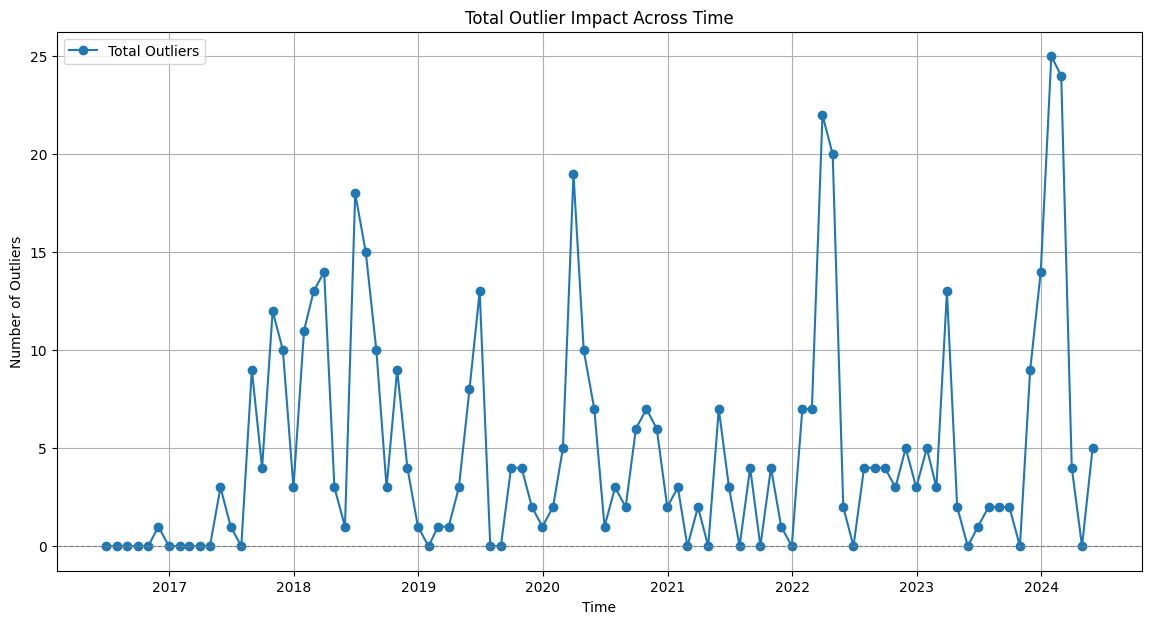

Outlier Impact Summary:
{'Total Outliers': 468, 'Max Outliers in a Period': 25, 'Periods with Outliers': 73, 'Percentage of Periods with Outliers': 76.04166666666666, 'Average Outliers per Period': 4.875}
Combined data and outlier summary have been saved successfully to: /content/drive/My Drive/Factordata/Combined_Outlier_Data.xlsx


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Set up the folder path in Google Drive
folder_path = r'/content/drive/My Drive/Factordata'

# Process each file for outlier detection
processed_files = []

def process_file(file_path):
    try:
        # Load the data
        df = pd.read_excel(file_path, sheet_name="FactorOutput")

        # Ensure the 'Date' column is in datetime format
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
        else:
            raise ValueError("The 'Date' column is missing in the file.")

        # List of factor columns
        factor_columns = ['Alpha..annualisiert.','Value.Growth', 'Small.Large', 'Momentum', 'Volatility']

        # Compute 12-month rolling mean, std, and detect outliers for each factor
        for col in factor_columns:
            df[f'{col}_Rolling_Mean'] = df[col].rolling(window=12, min_periods=1).mean()
            df[f'{col}_Rolling_Std'] = df[col].rolling(window=12, min_periods=1).std()
            df[f'{col}_Dynamic_Outlier'] = (
                (df[col] - df[f'{col}_Rolling_Mean']).abs() > 2 * df[f'{col}_Rolling_Std']
            )

        # Add a column to track the source file
        df['Source_File'] = os.path.basename(file_path)

        # Return the processed DataFrame
        return df

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None

# Iterate over all files and process them
processed_data = []
for filename in os.listdir(folder_path):
    if filename.endswith(".xlsx"):
        file_path = os.path.join(folder_path, filename)
        print(f"Processing file: {file_path}")
        processed_df = process_file(file_path)
        if processed_df is not None:
            processed_data.append(processed_df)

# Combine all processed data
if processed_data:
    combined_data = pd.concat(processed_data, ignore_index=True)

    # Ensure 'Date' is in datetime format and set as index
    combined_data['Date'] = pd.to_datetime(combined_data['Date'])
    combined_data.set_index('Date', inplace=True)

    # Aggregate outlier counts over time
    factor_columns = ['Alpha..annualisiert.','Value.Growth', 'Small.Large', 'Momentum', 'Volatility']
    combined_data['Total_Outliers'] = combined_data[[f'{col}_Dynamic_Outlier' for col in factor_columns]].sum(axis=1)
    monthly_outliers = combined_data['Total_Outliers'].resample('M').sum()  # Monthly aggregation

    # Step 4: Plot total outlier impact across time
    plt.figure(figsize=(14, 7))
    plt.plot(monthly_outliers.index, monthly_outliers, label="Total Outliers", marker='o')
    plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
    plt.title("Total Outlier Impact Across Time")
    plt.xlabel("Time")
    plt.ylabel("Number of Outliers")
    plt.legend()
    plt.grid()
    plt.show()

    # Step 5: Summarize outlier impact
    outlier_summary = {
        "Total Outliers": combined_data['Total_Outliers'].sum(),
        "Max Outliers in a Period": monthly_outliers.max(),
        "Periods with Outliers": (monthly_outliers > 0).sum(),
        "Percentage of Periods with Outliers": (monthly_outliers > 0).mean() * 100,
        "Average Outliers per Period": monthly_outliers.mean()
    }

    print("Outlier Impact Summary:")
    print(outlier_summary)

    # Save the combined data and outlier summary to an Excel file
    output_path = os.path.join(folder_path, "Combined_Outlier_Data.xlsx")
    combined_data.reset_index().to_excel(output_path, index=False, sheet_name="CombinedData")

    outlier_summary_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Value'])
    with pd.ExcelWriter(output_path, engine="openpyxl", mode="a") as writer:
        outlier_summary_df.to_excel(writer, sheet_name="Outlier_Summary")

    print(f"Combined data and outlier summary have been saved successfully to: {output_path}")

else:
    print("No data processed. Please check the input files.")


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# Set up the folder path
folder_path = r'/content/drive/My Drive/Factordata'

# Define a function to process each file for outlier detection
def process_file(file_path):
    try:
        # Load the data
        df = pd.read_excel(file_path, sheet_name="FactorOutput")

        # Ensure the 'Date' column is in datetime format
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
        else:
            raise ValueError("The 'Date' column is missing in the file.")

        # List of factor columns
        factor_columns = ['Alpha..annualisiert.','Value.Growth', 'Small.Large', 'Momentum', 'Volatility']

        # Compute 12-month rolling mean, std, and detect outliers for each factor
        for col in factor_columns:
            df[f'{col}_Rolling_Mean'] = df[col].rolling(window=12, min_periods=1).mean()
            df[f'{col}_Rolling_Std'] = df[col].rolling(window=12, min_periods=1).std()
            df[f'{col}_Dynamic_Outlier'] = (
                (df[col] - df[f'{col}_Rolling_Mean']).abs() > 1.5 * df[f'{col}_Rolling_Std']
            )

        # Add a column to track the source file
        df['Source_File'] = os.path.basename(file_path)

        return df

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None

# Process all files in the folder
processed_data = []
for filename in os.listdir(folder_path):
    if filename.endswith(".xlsx"):
        file_path = os.path.join(folder_path, filename)
        print(f"Processing file: {file_path}")
        processed_df = process_file(file_path)
        if processed_df is not None:
            processed_data.append(processed_df)

# Combine all processed data
if processed_data:
    combined_data = pd.concat(processed_data, ignore_index=True)

    # Ensure 'Date' is in datetime format and set as index
    combined_data['Date'] = pd.to_datetime(combined_data['Date'])
    combined_data.set_index('Date', inplace=True)

    # Create features for the ML model
    factor_columns = ['Alpha..annualisiert.','Value.Growth', 'Small.Large', 'Momentum', 'Volatility']
    features = combined_data[[
        f'{col}' for col in factor_columns
    ]].dropna()

    # Create anomaly labels by combining all outlier flags
    features['Anomaly_Label'] = combined_data[[
        f'{col}_Dynamic_Outlier' for col in factor_columns
    ]].any(axis=1).astype(int)

    # Split data into training and testing sets
    X = features.drop(columns=['Anomaly_Label'])
    y = features['Anomaly_Label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Apply SMOTE to balance the dataset
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # Train the Random Forest classifier
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_resampled, y_resampled)

    # Predict on the test set
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluate the model
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.2f}")

    # Save the combined data and outlier summary
    output_path = os.path.join(folder_path, "Combined_Outlier_Data_with_Model.xlsx")
    combined_data.reset_index().to_excel(output_path, index=False, sheet_name="CombinedData")

    print(f"Combined data and outlier summary have been saved successfully to: {output_path}")

else:
    print("No data processed. Please check the input files.")


Processing file: /content/drive/My Drive/Factordata/Pictet.xlsx
Processing file: /content/drive/My Drive/Factordata/creditsuisse.xlsx
Processing file: /content/drive/My Drive/Factordata/3645.xlsx
Processing file: /content/drive/My Drive/Factordata/Finreon.xlsx
Processing file: /content/drive/My Drive/Factordata/SGKB.xlsx
Processing file: /content/drive/My Drive/Factordata/IAM.xlsx
Processing file: /content/drive/My Drive/Factordata/21216.xlsx
Processing file: /content/drive/My Drive/Factordata/Vontobel.xlsx
Processing file: /content/drive/My Drive/Factordata/zCapital.xlsx
Processing file: /content/drive/My Drive/Factordata/GAM.xlsx
Processing file: /content/drive/My Drive/Factordata/Lo.xlsx
Processing file: /content/drive/My Drive/Factordata/SaraSelect.xlsx
Processing file: /content/drive/My Drive/Factordata/Model_Comparison.xlsx
Error processing file /content/drive/My Drive/Factordata/Model_Comparison.xlsx: Worksheet named 'FactorOutput' not found
Processing file: /content/drive/My Dr

In [4]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)  # Adjust contamination as needed
iso_labels = iso_forest.fit_predict(X)  # -1 = anomaly, 1 = normal
features['Anomaly_Label'] = (iso_labels == -1).astype(int)


In [5]:
from sklearn.svm import OneClassSVM

# Train One-Class SVM
one_class_svm = OneClassSVM(kernel="rbf", gamma=0.1, nu=0.05)  # Tune gamma and nu
one_class_labels = one_class_svm.fit_predict(X)  # -1 = anomaly, 1 = normal
features['Anomaly_Label'] = (one_class_labels == -1).astype(int)


In [6]:
for col in factor_columns:
    lower = combined_data[col].quantile(0.05)  # 5th percentile
    upper = combined_data[col].quantile(0.95)  # 95th percentile
    combined_data[f'{col}_Quantile_Outlier'] = ~combined_data[col].between(lower, upper)

# Combine all quantile-based outliers
features['Anomaly_Label'] = combined_data[[f'{col}_Quantile_Outlier' for col in factor_columns]].any(axis=1).astype(int)


In [7]:
# Initialize a dictionary to store metrics for each iteration
metrics_tracking = {'Iteration': [], 'Precision': [], 'Recall': [], 'F1-Score': [], 'ROC-AUC': [], 'New_Anomalies': []}

# Function to calculate and store metrics
def evaluate_model(model, X_test, y_test, y_proba, iteration, new_anomalies):
    from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

    y_pred = model.predict(X_test)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    metrics_tracking['Iteration'].append(iteration)
    metrics_tracking['Precision'].append(precision)
    metrics_tracking['Recall'].append(recall)
    metrics_tracking['F1-Score'].append(f1)
    metrics_tracking['ROC-AUC'].append(roc_auc)
    metrics_tracking['New_Anomalies'].append(new_anomalies)

    print(f"Iteration {iteration} Metrics:")
    print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}, ROC-AUC: {roc_auc:.2f}")


In [8]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Train initial model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate initial model
evaluate_model(model, X_test, y_test, y_proba, iteration=0, new_anomalies=0)

# Active learning iterations
for iteration in range(1, 3):  # Limit to 5 iterations for demonstration
    threshold = 0.8  # High-confidence anomaly threshold
    high_prob_indices = np.where(y_proba > threshold)[0]

    # Identify and validate new anomalies
    high_prob_samples = X_test.iloc[high_prob_indices]
    new_anomalies = len(high_prob_samples)  # Count new high-probability samples

    # Simulate manual validation (for now, label all as anomalies)
    validated_anomalies = high_prob_samples.index
    y_train.loc[validated_anomalies] = 1  # Add to training labels

    # Retrain the model
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluate updated model
    evaluate_model(model, X_test, y_test, y_proba, iteration, new_anomalies)


Iteration 0 Metrics:
Precision: 0.71, Recall: 0.83, F1-Score: 0.76, ROC-AUC: 0.71
Iteration 1 Metrics:
Precision: 0.63, Recall: 0.94, F1-Score: 0.75, ROC-AUC: 0.61
Iteration 2 Metrics:
Precision: 0.62, Recall: 0.99, F1-Score: 0.76, ROC-AUC: 0.59


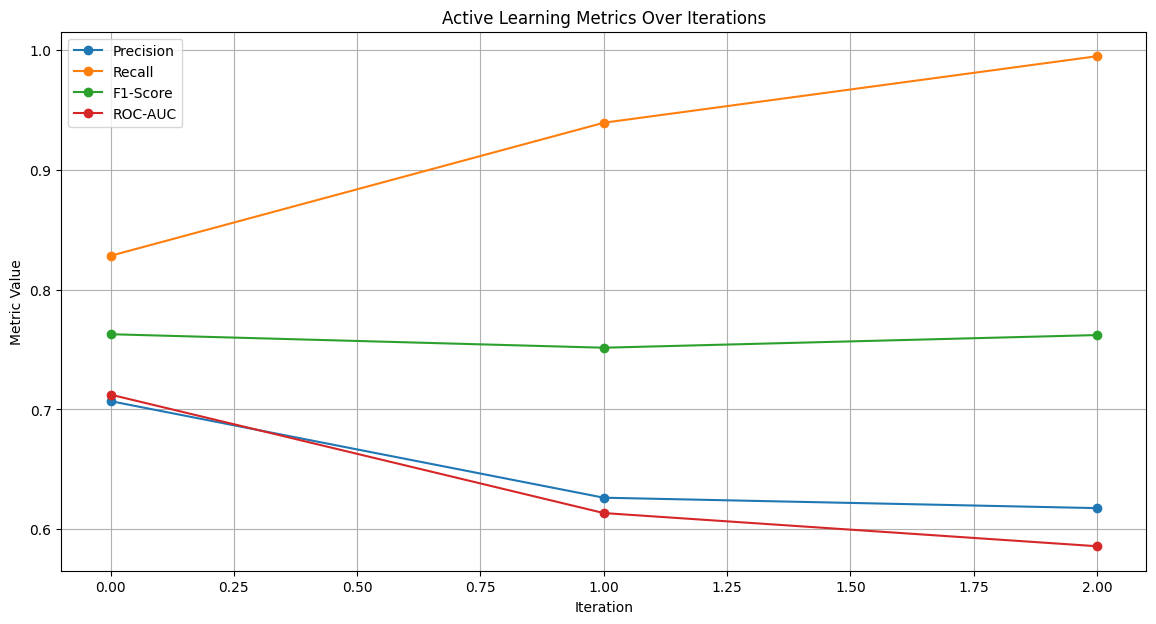

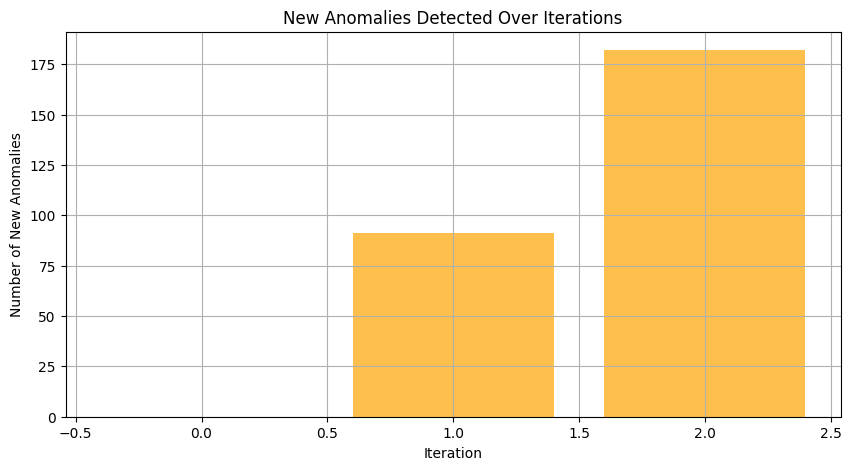

In [9]:
import matplotlib.pyplot as plt

# Convert metrics tracking to DataFrame
metrics_df = pd.DataFrame(metrics_tracking)

# Plot metrics over iterations
plt.figure(figsize=(14, 7))
for metric in ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    plt.plot(metrics_df['Iteration'], metrics_df[metric], label=metric, marker='o')

plt.title("Active Learning Metrics Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Metric Value")
plt.legend()
plt.grid()
plt.show()

# Plot new anomalies detected per iteration
plt.figure(figsize=(10, 5))
plt.bar(metrics_df['Iteration'], metrics_df['New_Anomalies'], color='orange', alpha=0.7)
plt.title("New Anomalies Detected Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Number of New Anomalies")
plt.grid()
plt.show()


In [10]:
# Create the anomaly label as a combination of outlier flags
factor_columns = ['Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatility']

# Ensure all outlier columns are available
outlier_columns = [f'{col}_Dynamic_Outlier' for col in factor_columns]
if not all(col in combined_data.columns for col in outlier_columns):
    print(f"Missing required outlier columns: {set(outlier_columns) - set(combined_data.columns)}")
    raise KeyError("Required outlier columns are missing.")

# Create the target variable
combined_data['Anomaly_Label'] = combined_data[outlier_columns].any(axis=1).astype(int)

# Drop rows with missing data
combined_data = combined_data.dropna(subset=factor_columns + ['Anomaly_Label'])

# Define features and labels
X = combined_data[factor_columns]
y = combined_data['Anomaly_Label']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Models to evaluate
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, kernel='rbf', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Initialize a dictionary to store results
results = {}

# Iterate through models and evaluate
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predictions and probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    # Store results
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df)

# Save results to an Excel file
output_path = os.path.join(folder_path, "Model_Comparison.xlsx")
results_df.to_excel(output_path, sheet_name="Comparison")
print(f"Model comparison results saved to: {output_path}")


Model Comparison:
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Random Forest        0.689024   0.706897  0.828283  0.762791  0.712335
Logistic Regression  0.588415   0.597523  0.974747  0.740883  0.553263
SVM                  0.618902   0.615142  0.984848  0.757282  0.594095
Gradient Boosting    0.658537   0.670635  0.853535  0.751111  0.662782
Model comparison results saved to: /content/drive/My Drive/Factordata/Model_Comparison.xlsx
